# Tech Challenge - Fase 4 - Predicao de Obesidade

Notebook completo com EDA, feature engineering, comparacao de modelos
e exportacao do pipeline final usado na aplicacao Streamlit.

Estrutura:
1. Importacoes e configuracao
2. Carga e descricao da base
3. Limpeza de dados
4. Analise exploratoria (EDA)
5. Feature engineering
6. Encoding das variaveis categoricas
7. Construcao do pipeline e comparacao de modelos
8. Avaliacao do modelo escolhido
9. Exportacao do pipeline serializado


## 1. Importacoes e configuracao


In [1]:
# Bibliotecas padrao do ecossistema de data science.
import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Modulos de modelagem do scikit-learn.
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Mostra todas as colunas no display do pandas.
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')


## 2. Carga e descricao da base

A base `Obesity.csv` esta na pasta `data/` na raiz do projeto. O arquivo
tem 2.111 registros e 17 colunas, sendo `Obesity` a variavel alvo.


In [2]:
# O caminho eh relativo ao notebook. Se o notebook estiver em
# `notebooks/`, sobe um nivel ate a raiz e busca a base em `data/`.
DATA_PATH = Path('..') / 'data' / 'Obesity.csv'

obesity = pd.read_csv(DATA_PATH)
print('Linhas e colunas:', obesity.shape)
obesity.head()


Linhas e colunas: (2111, 17)


,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [3]:
# Tipos das colunas e contagem de valores nao nulos.
obesity.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          2111 non-null   object 
 1   Age             2111 non-null   float64
 2   Height          2111 non-null   float64
 3   Weight          2111 non-null   float64
 4   family_history  2111 non-null   object 
 5   FAVC            2111 non-null   object 
 6   FCVC            2111 non-null   float64
 7   NCP             2111 non-null   float64
 8   CAEC            2111 non-null   object 
 9   SMOKE           2111 non-null   object 
 10  CH2O            2111 non-null   float64
 11  SCC             2111 non-null   object 
 12  FAF             2111 non-null   float64
 13  TUE             2111 non-null   float64
 14  CALC            2111 non-null   object 
 15  MTRANS          2111 non-null   object 
 16  Obesity         2111 non-null   object 
dtypes: float64(8), object(9)
memory u

In [4]:
# Estatisticas descritivas das colunas numericas.
obesity.describe().round(2)


,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.00,2111.00,2111.00,2111.00,2111.00,2111.00,2111.00,2111.00
mean,24.31,1.70,86.59,2.42,2.69,2.01,1.01,0.66
std,6.35,0.09,26.19,0.53,0.78,0.61,0.85,0.61
min,14.00,1.45,39.00,1.00,1.00,1.00,0.00,0.00
25%,19.95,1.63,65.47,2.00,2.66,1.58,0.12,0.00
50%,22.78,1.70,83.00,2.39,3.00,2.00,1.00,0.63
75%,26.00,1.77,107.43,3.00,3.00,2.48,1.67,1.00
max,61.00,1.98,173.00,3.00,4.00,3.00,3.00,2.00


In [5]:
# Valores unicos das colunas categoricas. Util para conferir os
# rotulos antes de aplicar qualquer encoding.
categorical_cols = ['Gender', 'family_history', 'FAVC', 'CAEC',
                    'SMOKE', 'SCC', 'CALC', 'MTRANS', 'Obesity']
for col in categorical_cols:
    print(f'{col}: {obesity[col].unique()}')


Gender: ['Female' 'Male']
family_history: ['yes' 'no']
FAVC: ['no' 'yes']
CAEC: ['Sometimes' 'Frequently' 'Always' 'no']
SMOKE: ['no' 'yes']
SCC: ['no' 'yes']
CALC: ['no' 'Sometimes' 'Frequently' 'Always']
MTRANS: ['Public_Transportation' 'Walking' 'Automobile' 'Motorbike' 'Bike']
Obesity: ['Normal_Weight' 'Overweight_Level_I' 'Overweight_Level_II'
 'Obesity_Type_I' 'Insufficient_Weight' 'Obesity_Type_II'
 'Obesity_Type_III']


## 3. Limpeza de dados

O dicionario de dados informa que algumas colunas categoricas (FCVC,
NCP, CH2O, FAF, TUE) aparecem com decimais por ruido na coleta. A
instrucao eh arredondar para o inteiro mais proximo. A coluna `Age`
tambem entra no arredondamento por consistencia.


In [6]:
# Arredonda as colunas que deveriam ser inteiras.
cols_to_round = ['Age', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
obesity[cols_to_round] = obesity[cols_to_round].round().astype(int)

# Remove duplicatas que possam vazar entre treino e teste.
antes = len(obesity)
obesity = obesity.drop_duplicates().reset_index(drop=True)
print(f'Duplicatas removidas: {antes - len(obesity)}')

# Confere se ha valores ausentes.
print('Valores nulos por coluna:')
print(obesity.isnull().sum())


Duplicatas removidas: 27
Valores nulos por coluna:
Gender            0
Age               0
Height            0
Weight            0
family_history    0
FAVC              0
FCVC              0
NCP               0
CAEC              0
SMOKE             0
CH2O              0
SCC               0
FAF               0
TUE               0
CALC              0
MTRANS            0
Obesity           0
dtype: int64


## 4. Analise exploratoria

A EDA tem dois objetivos: confirmar a qualidade da base e identificar
padroes que ajudem na construcao das features. Os mesmos graficos
alimentam o dashboard analitico do app.


/var/folders/12/8_7v6nbn4bvgk7rdr_yvzq1w0000gq/T/ipykernel_88248/3281885087.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=obesity, x='Obesity', order=ordered_classes,


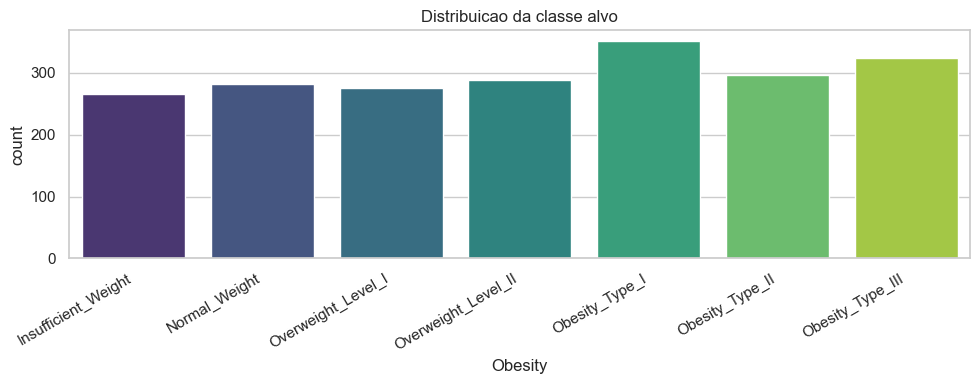

In [7]:
# Distribuicao da variavel alvo.
ordered_classes = [
    'Insufficient_Weight', 'Normal_Weight',
    'Overweight_Level_I', 'Overweight_Level_II',
    'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III',
]
plt.figure(figsize=(10, 4))
sns.countplot(data=obesity, x='Obesity', order=ordered_classes,
              palette='viridis')
plt.xticks(rotation=30, ha='right')
plt.title('Distribuicao da classe alvo')
plt.tight_layout()
plt.show()


/var/folders/12/8_7v6nbn4bvgk7rdr_yvzq1w0000gq/T/ipykernel_88248/1368303767.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=obesity['Obesity'], y=imc_provisorio, order=ordered_classes,


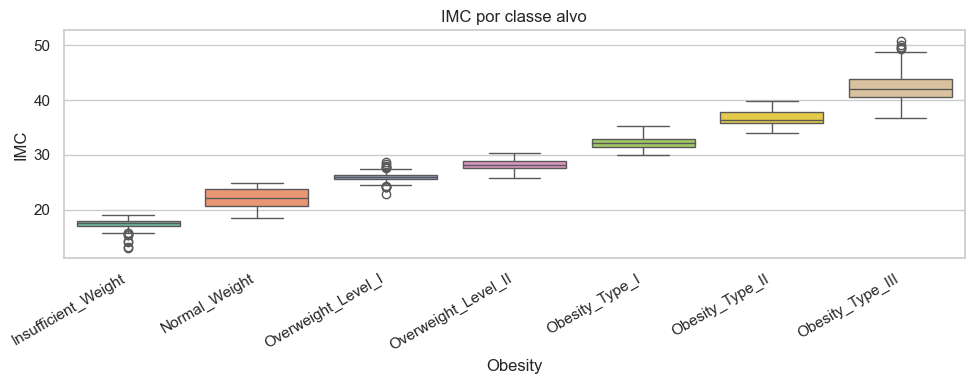

In [8]:
# Distribuicao de IMC por classe (calculo provisorio antes do bloco de
# feature engineering, apenas para visualizar a separacao).
imc_provisorio = obesity['Weight'] / obesity['Height']**2
plt.figure(figsize=(10, 4))
sns.boxplot(x=obesity['Obesity'], y=imc_provisorio, order=ordered_classes,
            palette='Set2')
plt.xticks(rotation=30, ha='right')
plt.ylabel('IMC')
plt.title('IMC por classe alvo')
plt.tight_layout()
plt.show()


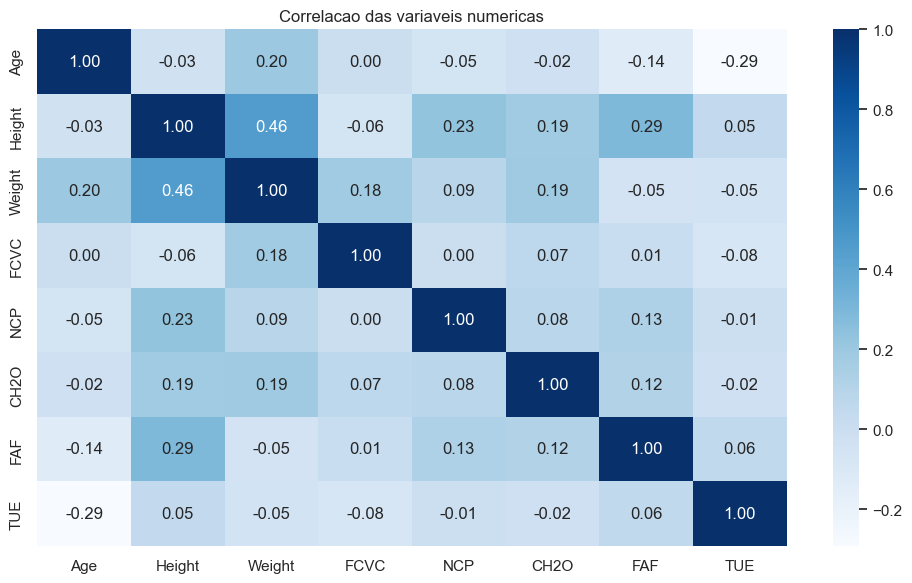

In [9]:
# Heatmap de correlacao das variaveis numericas originais.
num_cols = obesity.select_dtypes(include=['int64', 'float64']).columns
corr = obesity[num_cols].corr()
plt.figure(figsize=(10, 6))
sns.heatmap(corr, cmap='Blues', annot=True, fmt='.2f')
plt.title('Correlacao das variaveis numericas')
plt.tight_layout()
plt.show()


## 5. Feature engineering

Tres features derivadas alimentam o modelo:
- `imc`: indice de massa corporal classico (kg/m^2).
- `Healthy_Score`: soma de FCVC + FAF + CH2O. Eh um sinal simples e
  robusto que combina alimentacao saudavel, atividade fisica e hidratacao.
- `Sedentary_Index`: razao entre tempo de tela e atividade fisica
  (`TUE / (FAF + 1)`). O `+1` evita divisao por zero quando FAF == 0.


In [10]:
obesity['imc'] = obesity['Weight'] / (obesity['Height'] ** 2)
obesity['Healthy_Score'] = obesity['FCVC'] + obesity['FAF'] + obesity['CH2O']
obesity['Sedentary_Index'] = obesity['TUE'] / (obesity['FAF'] + 1)

obesity[['Weight', 'Height', 'imc', 'Healthy_Score', 'Sedentary_Index']].head()


,Weight,Height,imc,Healthy_Score,Sedentary_Index
0,64.0,1.62,24.386526,4,1.000000
1,56.0,1.52,24.238227,9,0.000000
2,77.0,1.80,23.765432,6,0.333333
3,87.0,1.80,26.851852,7,0.000000
4,89.8,1.78,28.342381,4,0.000000


## 6. Encoding das variaveis categoricas

As variaveis categoricas sao tratadas com mapeamentos manuais (em vez
de OneHotEncoder cego) porque varias preservam ordem natural de
intensidade (CAEC, CALC, MTRANS). Isso simplifica o modelo final e
torna os coeficientes mais interpretavel para a equipe medica.


In [11]:
# Mapeamentos.
mtrans_map = {'Walking': 3, 'Bike': 3, 'Public_Transportation': 2,
              'Automobile': 1, 'Motorbike': 1}
caec_map = {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3}
calc_map = {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3}
gender_map = {'Male': 0, 'Female': 1}
yesno_map = {'no': 0, 'yes': 1}

obesity['MTRANS_Code'] = obesity['MTRANS'].map(mtrans_map)
obesity['caec_code'] = obesity['CAEC'].map(caec_map)
obesity['calc_code'] = obesity['CALC'].map(calc_map)
obesity['gender_binary'] = obesity['Gender'].map(gender_map)
for col in ['family_history', 'FAVC', 'SMOKE', 'SCC']:
    obesity[col] = obesity[col].map(yesno_map)

obesity.head()


,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity,imc,Healthy_Score,Sedentary_Index,MTRANS_Code,caec_code,calc_code,gender_binary
0,Female,21,1.62,64.0,1,0,2,3,Sometimes,0,2,0,0,1,no,Public_Transportation,Normal_Weight,24.386526,4,1.000000,2,1,0,1
1,Female,21,1.52,56.0,1,0,3,3,Sometimes,1,3,1,3,0,Sometimes,Public_Transportation,Normal_Weight,24.238227,9,0.000000,2,1,1,1
2,Male,23,1.80,77.0,1,0,2,3,Sometimes,0,2,0,2,1,Frequently,Public_Transportation,Normal_Weight,23.765432,6,0.333333,2,1,2,0
3,Male,27,1.80,87.0,0,0,3,3,Sometimes,0,2,0,2,0,Frequently,Walking,Overweight_Level_I,26.851852,7,0.000000,3,1,2,0
4,Male,22,1.78,89.8,0,0,2,1,Sometimes,0,2,0,0,0,Sometimes,Public_Transportation,Overweight_Level_II,28.342381,4,0.000000,2,1,1,0


## 7. Pipeline e comparacao de modelos

Comparamos tres modelos com `GridSearchCV` (5 folds estratificados) e
metrica `f1_macro`. A escolha cobre tres familias de algoritmos:
- **LogisticRegression**: linha de base linear, interpretavel.
- **RandomForest**: ensemble por bagging.
- **GradientBoosting**: ensemble por boosting.


In [12]:
feature_columns = [
    'Age', 'Height', 'NCP',
    'imc', 'Healthy_Score', 'Sedentary_Index',
    'MTRANS_Code', 'caec_code', 'calc_code', 'gender_binary',
    'family_history', 'FAVC', 'SMOKE', 'SCC',
]
numeric_columns = ['Age', 'Height', 'NCP', 'imc',
                   'Healthy_Score', 'Sedentary_Index']

X = obesity[feature_columns].copy()
y = obesity['Obesity'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print('Treino:', X_train.shape, ' Teste:', X_test.shape)


Treino: (1667, 14)  Teste: (417, 14)


In [13]:
preprocessor = ColumnTransformer(
    transformers=[('num', StandardScaler(), numeric_columns)],
    remainder='passthrough',
)

candidates = {
    'logistic_regression': {
        'estimator': LogisticRegression(max_iter=2000, random_state=42),
        'param_grid': {
            'classifier__C': [0.1, 1.0, 10.0],
            'classifier__penalty': ['l2'],
            'classifier__solver': ['lbfgs'],
        },
    },
    'random_forest': {
        'estimator': RandomForestClassifier(random_state=42, n_jobs=-1),
        'param_grid': {
            'classifier__n_estimators': [200, 400],
            'classifier__max_depth': [None, 10, 20],
            'classifier__min_samples_split': [2, 5],
        },
    },
    'gradient_boosting': {
        'estimator': GradientBoostingClassifier(random_state=42),
        'param_grid': {
            'classifier__n_estimators': [150, 300],
            'classifier__learning_rate': [0.05, 0.1],
            'classifier__max_depth': [3, 5],
        },
    },
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}
best_overall = {'name': None, 'score': -np.inf, 'estimator': None}

for name, cfg in candidates.items():
    print(f'\nAvaliando {name}...')
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', cfg['estimator']),
    ])
    grid = GridSearchCV(pipeline, cfg['param_grid'], cv=cv,
                       scoring='f1_macro', n_jobs=-1, refit=True)
    grid.fit(X_train, y_train)
    y_pred = grid.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    print(f'  best params  : {grid.best_params_}')
    print(f'  cv f1_macro  : {grid.best_score_:.4f}')
    print(f'  test accuracy: {acc:.4f}')
    print(f'  test f1_macro: {f1:.4f}')
    results[name] = {
        'best_params': grid.best_params_,
        'cv_f1_macro': grid.best_score_,
        'test_accuracy': acc,
        'test_f1_macro': f1,
        'estimator': grid.best_estimator_,
        'y_pred': y_pred,
    }
    if f1 > best_overall['score']:
        best_overall = {'name': name, 'score': f1,
                        'estimator': grid.best_estimator_}

print(f'\nMelhor modelo: {best_overall["name"]} (f1_macro={best_overall["score"]:.4f})')



Avaliando logistic_regression...


  best params  : {'classifier__C': 10.0, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}
  cv f1_macro  : 0.9417
  test accuracy: 0.9424
  test f1_macro: 0.9405

Avaliando random_forest...


  best params  : {'classifier__max_depth': None, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
  cv f1_macro  : 0.9732
  test accuracy: 0.9736
  test f1_macro: 0.9727

Avaliando gradient_boosting...


  best params  : {'classifier__learning_rate': 0.05, 'classifier__max_depth': 5, 'classifier__n_estimators': 150}
  cv f1_macro  : 0.9734
  test accuracy: 0.9760
  test f1_macro: 0.9749

Melhor modelo: gradient_boosting (f1_macro=0.9749)


## 8. Avaliacao do modelo escolhido

Imprimimos o classification_report completo e plotamos a matriz de
confusao para verificar como o modelo se comporta em cada classe.


In [14]:
best_name = best_overall['name']
best_estimator = results[best_name]['estimator']
y_pred = results[best_name]['y_pred']

print(f'Classification report - {best_name}:')
print(classification_report(y_test, y_pred))


Classification report - gradient_boosting:
                     precision    recall  f1-score   support

Insufficient_Weight       1.00      1.00      1.00        53
      Normal_Weight       0.97      1.00      0.98        56
     Obesity_Type_I       1.00      0.99      0.99        70
    Obesity_Type_II       0.97      1.00      0.98        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.98      0.87      0.92        55
Overweight_Level_II       0.92      0.98      0.95        58

           accuracy                           0.98       417
          macro avg       0.98      0.98      0.97       417
       weighted avg       0.98      0.98      0.98       417



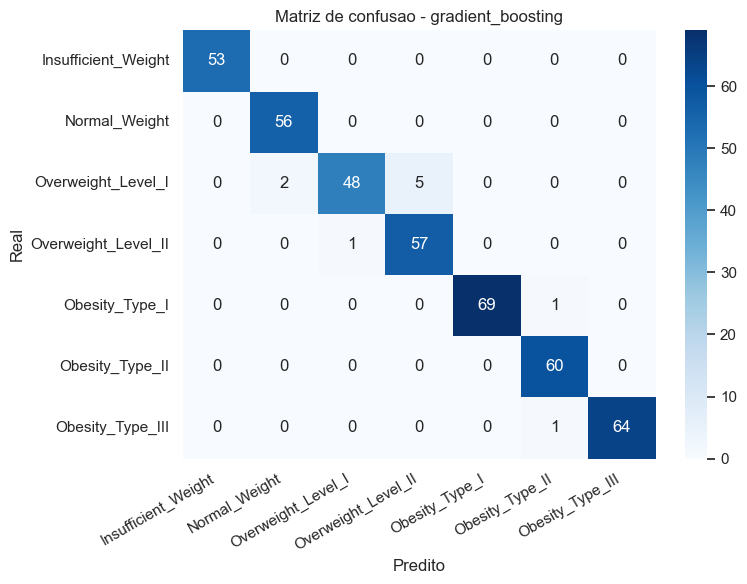

In [15]:
cm = confusion_matrix(y_test, y_pred, labels=ordered_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=ordered_classes, yticklabels=ordered_classes)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title(f'Matriz de confusao - {best_name}')
plt.tight_layout()
plt.show()


In [16]:
# Tabela comparativa simples entre os tres modelos.
summary = pd.DataFrame([
    {
        'modelo': name,
        'cv_f1_macro': round(info['cv_f1_macro'], 4),
        'test_accuracy': round(info['test_accuracy'], 4),
        'test_f1_macro': round(info['test_f1_macro'], 4),
    }
    for name, info in results.items()
])
summary


,modelo,cv_f1_macro,test_accuracy,test_f1_macro
0,logistic_regression,0.9417,0.9424,0.9405
1,random_forest,0.9732,0.9736,0.9727
2,gradient_boosting,0.9734,0.9760,0.9749


## 9. Exportacao do pipeline serializado

O pipeline final eh salvo em `models/best_pipeline.joblib` para que a
aplicacao Streamlit consiga consumi-lo sem retreinar.


In [17]:
MODELS_DIR = Path('..') / 'models'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(best_estimator, MODELS_DIR / 'best_pipeline.joblib')
print('Pipeline salvo em models/best_pipeline.joblib')


Pipeline salvo em models/best_pipeline.joblib


---
Para reproduzir localmente:
```bash
python -m venv venv
source venv/bin/activate
pip install -r requirements.txt
python train_model.py
streamlit run app.py
```
